# Chapter 3-4

In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sklearn

## Working with Scikit.learn

In this chapter, we will explore more machine learning algorithm, specifically classification algorithm using Scikit.learn. Lets revisit our Iris data set that is already included from scikit.learn.

In [114]:
from sklearn import datasets

iris = datasets.load_iris()
X = iris.data[:,[2,3]]
y = iris['target']
print(X)
print(y)


[[1.4 0.2]
 [1.4 0.2]
 [1.3 0.2]
 [1.5 0.2]
 [1.4 0.2]
 [1.7 0.4]
 [1.4 0.3]
 [1.5 0.2]
 [1.4 0.2]
 [1.5 0.1]
 [1.5 0.2]
 [1.6 0.2]
 [1.4 0.1]
 [1.1 0.1]
 [1.2 0.2]
 [1.5 0.4]
 [1.3 0.4]
 [1.4 0.3]
 [1.7 0.3]
 [1.5 0.3]
 [1.7 0.2]
 [1.5 0.4]
 [1.  0.2]
 [1.7 0.5]
 [1.9 0.2]
 [1.6 0.2]
 [1.6 0.4]
 [1.5 0.2]
 [1.4 0.2]
 [1.6 0.2]
 [1.6 0.2]
 [1.5 0.4]
 [1.5 0.1]
 [1.4 0.2]
 [1.5 0.2]
 [1.2 0.2]
 [1.3 0.2]
 [1.4 0.1]
 [1.3 0.2]
 [1.5 0.2]
 [1.3 0.3]
 [1.3 0.3]
 [1.3 0.2]
 [1.6 0.6]
 [1.9 0.4]
 [1.4 0.3]
 [1.6 0.2]
 [1.4 0.2]
 [1.5 0.2]
 [1.4 0.2]
 [4.7 1.4]
 [4.5 1.5]
 [4.9 1.5]
 [4.  1.3]
 [4.6 1.5]
 [4.5 1.3]
 [4.7 1.6]
 [3.3 1. ]
 [4.6 1.3]
 [3.9 1.4]
 [3.5 1. ]
 [4.2 1.5]
 [4.  1. ]
 [4.7 1.4]
 [3.6 1.3]
 [4.4 1.4]
 [4.5 1.5]
 [4.1 1. ]
 [4.5 1.5]
 [3.9 1.1]
 [4.8 1.8]
 [4.  1.3]
 [4.9 1.5]
 [4.7 1.2]
 [4.3 1.3]
 [4.4 1.4]
 [4.8 1.4]
 [5.  1.7]
 [4.5 1.5]
 [3.5 1. ]
 [3.8 1.1]
 [3.7 1. ]
 [3.9 1.2]
 [5.1 1.6]
 [4.5 1.5]
 [4.5 1.6]
 [4.7 1.5]
 [4.4 1.3]
 [4.1 1.3]
 [4.  1.3]
 [4.4 1.2]

Lets now split our data into that our training sets and test sets. We will import the function from train_test_split, which shuffles our data as well.

In [115]:
from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(X,y, test_size = 0.3, random_state=1, stratify = y)



Scikit.learn also provides a libary for feature scaling. Using StandardScaler, we can standardize our features like we did in Chapter 2.

In [116]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(Xtrain) #Store mean and sd in instance variables

#Use the mean and sd to transform the data set
Xtrain = sc.transform(Xtrain)
Xtest = sc.transform(Xtest)

With all of the preprocessing out of the way, lets recreate our Perceptron:

In [117]:
from sklearn.linear_model import Perceptron
ppn = Perceptron(eta0=0.1, random_state = 1)
ppn.fit(Xtrain, ytrain)

Perceptron(eta0=0.1, random_state=1)

Lets see how accurate it really is

In [118]:
ypred = ppn.predict(Xtest)
print('Misclassified examples: %d' %(ytest != ypred).sum())

Misclassified examples: 1


## Multiclassification (One-vs-Rest)

Before moving on, lets clarify how our perceptron was able to classify more than 2 categories. It does it using One-vs-Rest (OvR). Lets say we have K-classes,then how to do multiclassification is to have "seperate" perceptrons for each class:
- Class 1 vs Not Class 1
- Class 2 vs Not Class 2
- Class 3 vs Not Class 3

We do this for all classes. In order to classify for each cases, we train K-seperate perceptrons, each with its own ($w_k,b_k$). Thus:

$$
\hat{y}_k = \sigma(z) =
\begin{cases}
1 & \text{if } (w_k \cdot x +b_k) \geq 0 \\
0 & \text{otherwise}
\end{cases}
$$

Our updating rule is the same as if we are working with a single perceptron. In order to best pick which, we use the arguement:

$$
\hat{y} = \arg \max_k (w_k \cdot x + b_k)
$$

## Working with Scikit.learn (Continuation)

Lets plot our decision graph and see how it works:

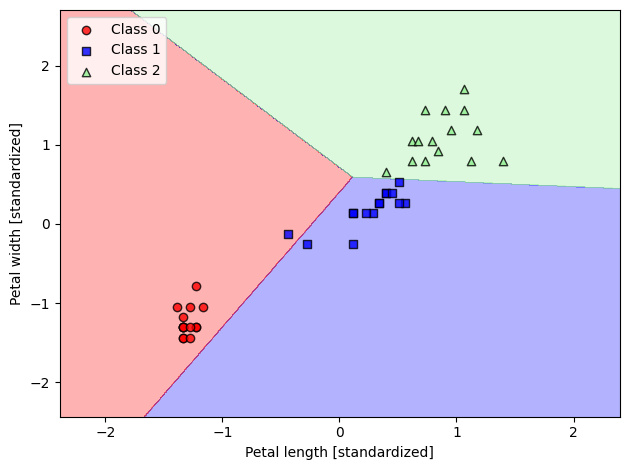

In [119]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

def plot_decision(X, y , classifier, test = None, resolution = 0.005, test_idx = 0):
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    x1_min, x1_max = X[:,0].min()-1, X[:,0].max() + 1
    x2_min, x2_max = X[:,1].min()-1, X[:,1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution), np.arange(x2_min, x2_max, resolution)) #Meshgrid

    grid = np.array([xx1.ravel(),xx2.ravel()]).T
    lab = classifier.predict(grid)
    lab = lab.reshape(xx1.shape)

    #Plotting
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    
    #plot the points:
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
            y=X[y == cl, 1],
            alpha=0.8,
            c=colors[idx],
            marker=markers[idx],
            label=f'Class {cl}',
            edgecolor='black')


plot_decision(X=Xtest, y=ytest, classifier=ppn, test_idx=range(105, 150))

plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()





Remember that if our perceptron is not able to linearly seperate its classes, it will never converge.

## Logistic Regression (For Classification)

Despite its name, Logistic Regression is used for classification, not for regression. Although it is used for binary classification, it is easy to be used for multiclassification as well. With Logistic Regression, we are dealing with probability:

$$
P:= P(y=1 | x)
$$
Where x is our feature, and y=1 representing a positive event (Like a patient testing positive). lets now define the $logit$ function:
$$
\text{logit}(p) = \ln\frac{p}{1-p}
$$

We assume the relation between Logit and wx + b because it is the simplest way to transform a linear combination of features into a valid probability between 0 and 1.
$$
\text{logit}(p) = w\cdot x + b
$$

Using the inverse of logit, we can isolate p:
$$
\text{logit}^{-1}(z) = \sigma(z) = \frac{1}{1+e^{-z}} = p
$$

We call this the sigmoid function. The core of Logistic Regression is the same as the adaline model from Chapter 2, except $\sigma$ is defined now as the sigmoid function. As a reminder, our prediction is the following:
$$
\hat{y} =
\begin{cases}
1 & \text{if } \sigma(z) \geq 0.5 \\
0 & \text{otherwise}
\end{cases}
$$

In fact, this is exactly equivalent to our original threshold function:

$$
\hat{y} =
\begin{cases}
1 & \text{if } z \geq 0 \\
0 & \text{otherwise}
\end{cases}
$$

Lets now define a Likelihood fucntion that we are tring to maximize:

$$
\mathcal{L}(w,b |x) := p(y|x;w,b) = \prod_{i=1}^n p(y^{(i)} | x^{(i)}; w,b) 
$$

Recall that y, x, and w are vectors, where each event is assumed to be conditionally independent, so $p(y|x) = p(y_1|x_1) \cdot p(y_2|x_2)\cdot...\cdot p(y_n|x_n)$

Also notice that y can only take on a value of 0 or 1. The probability of 1 is $\sigma(z^{(i)})$, $1 - \sigma(z^{(i)})$ for 0. This exactly matches the Bernoulli distribution.

$$
\mathcal{L}(w,b |x) = \prod_{i=1}^n \sigma(z^{(i)})^{y^{(i)}} \cdot (1 - \sigma(z^{(i)})^{1 - y^{(i)}})
$$

From these results, it is obvious that we want to maximize our Likelihood function, because consistently getting the correct match with 100% confidence will yield 1, while getting every matches wrong with 100% confidence will yield a score of 0.

In practice however, we prefer to use the Log-Maximum likelihood function:

$$
l(\mathbf{w}, b | \mathbf{x}) = \log \mathcal{L}(\mathbf{w}, b | \mathbf{x}) = \sum_{i=1}^{n} [y^{(i)} \log(\sigma(z^{(i)})) + (1 - y^{(i)}) \log(1 - \sigma(z^{(i)}))]
$$

While we can perform normal gradient descend to maximize the log-maximum function and find the ideal weights and biases, we can also convert this into our familiar "Loss function."

$$
L(\mathbf{w}, b) = \frac{1}{n} \sum_{i=1}^{n} [-y^{(i)} \log(\sigma(z^{(i)})) - (1 - y^{(i)}) \log(1 - \sigma(z^{(i)}))]
$$

Lets Revisit the AdalineGD function from Chapter 2, and replace our original loss function with the new one.

In [120]:
class LogisticRegressionGD:

    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float64(0.)
        self.losses_ = []
        for i in range(self.n_iter):
            net_input = self.net_input(X)
            output = self.activation(net_input)
            errors = (y - output)
            self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * 2.0 * errors.mean()
            loss = (-y.dot(np.log(output)) - ((1 - y).dot(np.log(1 - output)))/ X.shape[0])
            self.losses_.append(loss)
        return self
    
    def net_input(self,X):
        return np.dot(X, self.w_) + self.b_
    
    def activation(self, z):
        return 1. / (1. + np.exp(-np.clip(z, -250, 250)))
    
    def predict(self, X):
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

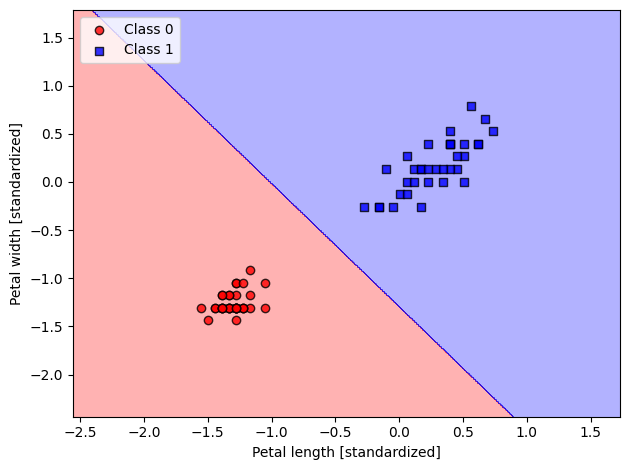

In [121]:
# Filtering the dataset for a binary subset (classes 0 and 1)
X_train_01_subset = Xtrain[(ytrain == 0) | (ytrain == 1)]
y_train_01_subset = ytrain[(ytrain == 0) | (ytrain == 1)]

# Initializing the Logistic Regression Gradient Descent model
lrgd = LogisticRegressionGD(eta=0.3, n_iter=1000, random_state=1)

# Training the model
lrgd.fit(X_train_01_subset, y_train_01_subset)

# Plotting decision regions
plot_decision(X=X_train_01_subset, y=y_train_01_subset, classifier=lrgd)

# Formatting the plot
plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

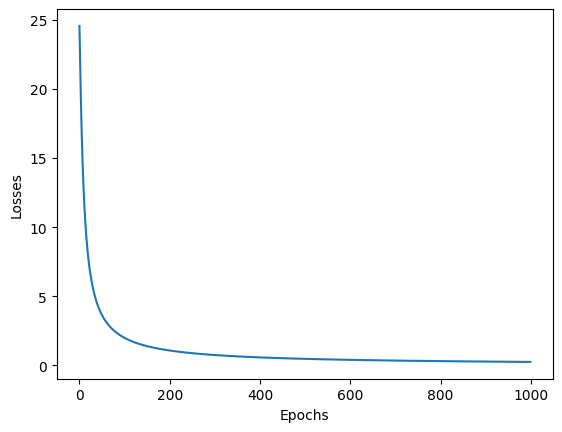

Final loss:  0.25617060880658504


In [122]:
plt.plot(range(lrgd.n_iter),lrgd.losses_)
plt.ylabel('Losses')
plt.xlabel('Epochs')
plt.show()
print("Final loss: ", lrgd.losses_[lrgd.n_iter-1])

Lets now use Scikit.learn to view how it does when there are multiple classes:

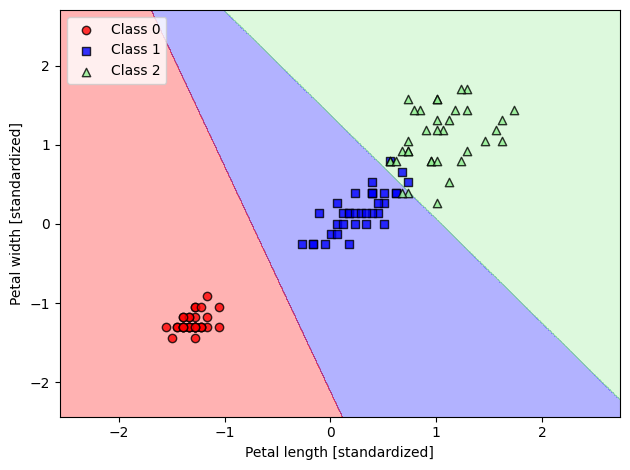

[[2.99777989e-11 1.42897256e-01 8.57102744e-01]
 [8.35084580e-01 1.64915420e-01 1.94230887e-16]
 [8.49501353e-01 1.50498647e-01 8.02239175e-18]
 [6.38802193e-07 8.20967342e-01 1.79032019e-01]
 [7.24444609e-06 9.95210178e-01 4.78257788e-03]
 [1.10415990e-04 9.99782589e-01 1.06995241e-04]
 [1.62907307e-10 3.66351798e-01 6.33648201e-01]
 [2.32463598e-06 9.73651785e-01 2.63458903e-02]
 [8.42512755e-10 2.57639286e-01 7.42360713e-01]
 [8.89035178e-01 1.10964822e-01 9.19635537e-18]]
[2 0 0 1 1 1 2 1 2 0]
[2 0 0 2 1 1 2 1 2 0]


In [123]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

base_model = LogisticRegression(C=1000.0, solver='lbfgs')
lr = OneVsRestClassifier(base_model)
lr.fit(Xtrain, ytrain)

plot_decision(Xtrain,ytrain, classifier=lr, test_idx=range(105, 150))

plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

print(lr.predict_proba(Xtest[:10, :]))
print(lr.predict(Xtest[:10, :]))
print(ytest[:10])


<div align="center">
  <img src="Medias/LogisticRegression.png" width="600">
</div>

## Overfitting and Regularization

Overfitting is a common problem in machine learning, where a model performs well on training data but does not generalize well to unseen data (test data). If a model suffers from overfitting, we also say that the model has a high variance, which can be caused by having too many parameters, leading to a model that is too complex given the underlying data.

Similarly, our model can also suffer from underfitting (high bias), which means that our model is not complex enough to capture the pattern in the training data well and therefore also suffers from low performance on unseen data.

This is most captured in the Bias-Variance trade off:

$$
E_{\hat{f}}\left[(y - \hat{f}(x))^2\right] = E_{\hat{f}}\left[(f(x) + \epsilon - \hat{f}(x))^2\right]
$$

Here, $y = f(x) + \epsilon$ describes the relation between the target/label and its features with a perfect prediction function $f$. $\epsilon$ is irriducible noise however, and so f(x) and y won't ever be exact, and its $E[\epsilon] = 0$ by definition. $\hat{f}(x)$ is our prediction model. The equation above thus represent the expected value of our error. Note that for convinience, $Error = (f(x) + \epsilon - \hat{f}(x))^2$, and $E = E_{\hat{f}, \epsilon}$. As such, we also assume x is fixed.

$$E[ error ] = E\left[(f(x) - \hat{f}(x))^2\right] + 2E\left[\epsilon(f(x) - \hat{f}(x))\right] + E[\epsilon^2]$$

$$E[ error ] = E\left[(f(x) - \hat{f}(x))^2\right] + E[\epsilon^2]$$

This leads us to our ultimate results:

$$E[(y - \hat{f}(x))^2] = \text{Bias}[\hat{f}(x)]^2 + \text{Var}[\hat{f}(x)] + \sigma^2$$

Where
$$\text{Bias}[\hat{f}(x)] = E[\hat{f}(x)] - f(x)$$


$$\text{Var}[\hat{f}(x)] = E[\hat{f}(x)^2] - E[\hat{f}(x)]^2$$

$$\sigma^2 = E[\epsilon^2]$$


Summary:

$$E\left[(y - \hat{f}(x))^2\right] = \underbrace{\left(E[\hat{f}(x)] - f(x)\right)^2}_{\text{Bias}^2} + \underbrace{E\left[(\hat{f}(x) - E[\hat{f}(x)])^2\right]}_{\text{Variance}} + \underbrace{\sigma^2}_{\text{Irreducible Error}}$$

Statistically, $\text{Bias}(f(x)) = E[f(x)] - x$, which measures the accuracy to which the model predict the correct value.

In the context of machine learning models, variance measures the consistency (or variability) of the model prediction for classifying a particular example if we retrain the model multiple times, for example, on different subsets of the training dataset. We can say that the model is sensitive to the randomness in the training data. In contrast, bias measures how far off the predictions are from the correct values in general if we rebuild the model multiple times on different training datasets

One way to fine-tune this bias-variance trade off is to use a regularization, which forces our model to compromise. The point of a regularization is to penalize large weight values, since it. One example is the $l^2$ regularization.

$$
\frac{\lambda}{2n} \|w\|_{2}^2 = \frac{\lambda}{2n} \sum_{j=1}^n w_j^2
$$

Note that for a regularization to properly work, we need our data to be standardized. Here $\lambda$ is the regularization parameter. We simply add this regularization to our original Loss function.

The parameter C in scikit.learn is inversely proportional to $\lambda$. 

[[ 9.45924144e-05  5.76503140e-05]
 [ 9.42695446e-04  5.73656938e-04]
 [ 9.13731247e-03  5.44062674e-03]
 [ 7.06186259e-02  3.39772295e-02]
 [ 3.09464540e-01 -3.12493444e-02]
 [ 1.15734013e+00 -8.20053469e-01]
 [ 2.16048235e+00 -1.82179148e+00]
 [ 2.41082803e+00 -2.07443668e+00]
 [ 2.44017125e+00 -2.10409864e+00]
 [ 2.44315771e+00 -2.10711805e+00]]


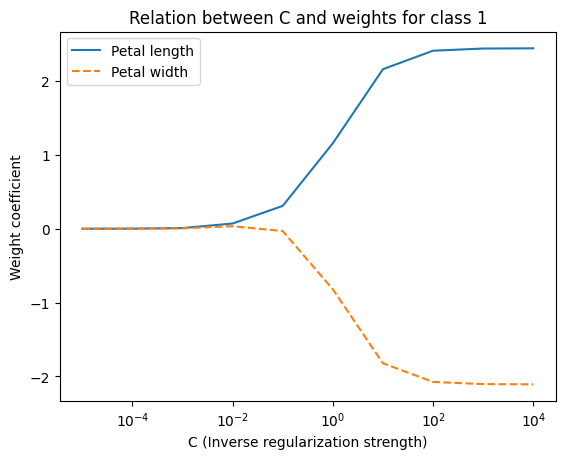

In [124]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
import numpy as np
import matplotlib.pyplot as plt

weights, params = [], []

for c in np.arange(-5, 5):
    # 'C' is the inverse of regularization strength (1/lambda)
    base_model = LogisticRegression(C=10.**c, random_state=1)
    lr = OneVsRestClassifier(base_model)
    lr.fit(Xtrain, ytrain)
    
    # Storing weights for class 1
    weights.append(lr.estimators_[1].coef_)
    params.append(10.**c)

weights = np.array(weights)
weights = weights.reshape(10,2)

print(weights)

# Plotting
plt.plot(params, weights[:,0], label='Petal length')
plt.plot(params, weights[:,1], linestyle='--', label='Petal width')

plt.xscale('log')
plt.xlabel('C (Inverse regularization strength)')
plt.ylabel('Weight coefficient')
plt.legend(loc='upper left')
plt.title("Relation between C and weights for class 1")
plt.show()

We clearly see from this that as C gets smaller, and thus $\lambda$ gets bigger, the weight coefficient converges to 0.

## GLM and extension of Linear Model

Whereas before we have derived some equations such as $z = w\cdot x + b$ and the Logistic Regression function, both of which are just a generalization of what we call GLM, Generalized Linear Model. Before starting, lets analyze a simple a data set where linear regression works very well.

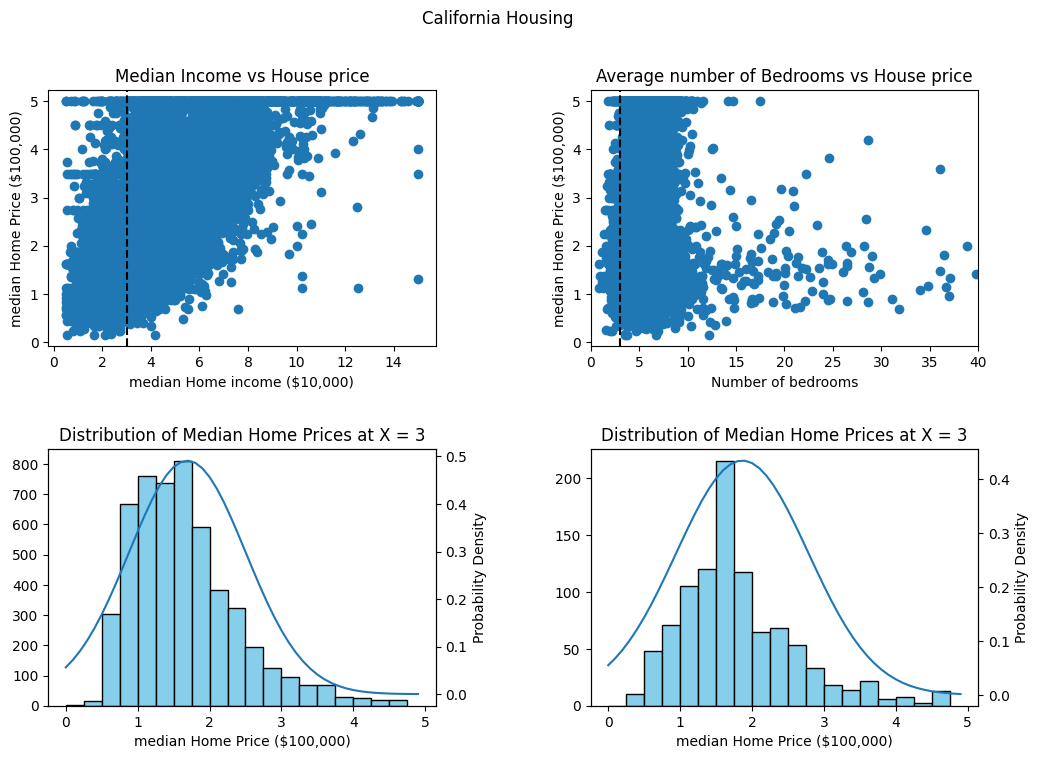

In [ ]:
from sklearn.datasets import fetch_california_housing
from scipy.stats import norm

data = fetch_california_housing()
X, y = fetch_california_housing(return_X_y=True)
x0 = 3
margin = 0.5

mask1 = (X[:,0] < x0 + margin) & (X[:,0] > x0 - margin)
mask2 = (X[:,2] < x0 + margin) & (X[:,2] > x0 - margin)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12,8))

plt.subplots_adjust(
    hspace=0.4,   # vertical gap
    wspace=0.4    # horizontal gap
)

bins = np.arange(0, 5, 0.25)

axes[0,0].scatter(X[:,0], y)
axes[0,1].scatter(X[:,2], y)
axes[1,0].hist(y[mask1], bins=bins, edgecolor='black', color='skyblue') #bmi
axes[1,1].hist(y[mask2], bins=bins, edgecolor='black', color='skyblue') #s5

#title
axes[0,0].set_title("Median Income vs House price")
axes[0,0].set_ylabel("median Home Price ($100,000)")
axes[0,0].set_xlabel("median Home income ($10,000)")
axes[0,0].axvline(x=x0, color='black', linestyle='--')

axes[0,1].set_title("Average number of Bedrooms vs House price")
axes[0,1].set_ylabel("median Home Price ($100,000)")
axes[0,1].set_xlabel("Number of bedrooms")
axes[0,1].set_xlim(0,40)
axes[0,1].axvline(x=x0, color='black', linestyle='--')

#Distribution curves

mu = np.mean(y[mask1])
sigma = np.std(y[mask1])
pdf1 = norm.pdf(np.arange(0,5,0.1), mu, sigma)

axes[1,0].set_xlabel("median Home Price ($100,000)")
axes[1,0].set_title(f"Distribution of Median Home Prices at X = {x0}")
ax2 = axes[1,0].twinx()
ax2.plot(np.arange(0,5,0.1), pdf1)
ax2.set_ylabel("Probability Density")

mu = np.mean(y[mask2])
sigma = np.std(y[mask2])
pdf2 = norm.pdf(np.arange(0,5,0.1), mu, sigma)

axes[1,1].set_xlabel("median Home Price ($100,000)")
axes[1,1].set_title(f"Distribution of Median Home Prices at X = {x0}")
ax2 = axes[1,1].twinx()
ax2.plot(np.arange(0,5,0.1), pdf2)
ax2.set_ylabel("Probability Density")


fig.suptitle("California Housing")

plt.show()


We see from the graphs above, $Y|X_1 \sim \text{Normal}(\mu_1, \sigma^2_1)$ and $Y|X_2 \sim \text{Normal}(\mu_2, \sigma^2_2)$ Where $X_1$ is the median home income, while $X_2$ is the average numbers of bedrooms, and $Y$ is the median home price. We know when $Y$ is conditioned upon $X_1$ or $X_2$, it distributed normally since for a fixed value of $X_1$ and $X_2$, all nearby y values  within our dataset forms a Gaussian curve.

From this discovery, we can find a machine learning model based on how our data is distributed, such that $h_w(x) = E[y|x;w]$. Intuatively, it makes sense: our prediction at x is simply the expected value of y, found using  the conditional probability of $p(y|x;w)$.

We can even go broader however and introduce the exponential family of distribution, which are any pdf that can be expressed in the form:

$$
p(y;\eta) = b(y) \exp(\eta^T \cdot T(y) - a(\eta))
$$
where

$$T(y) \text{ is called the sufficient statistic}$$
$$a(\eta) \text{ is the log partition function}$$

This gives us enough context now to fully explain GLM, which gives us a way to create predictive models off of the distribution of $Y|X$. It assumes the following:

$$
\begin{aligned}
1. & \quad Y|X;w \sim \text{ExponentialFamily}(\eta) \\
2. & \quad h_w(x) = E[T(y)|x;w] \\
3. & \quad \eta = w \cdot x
\end{aligned}
$$

Note that we define $w_0x_0 = b$. Often time, $\eta$ is a vector, so $\eta_i = w_i \cdot x$. When we make these assumptions, our familar prediction functions shows up.

### linear Regression Function

We first assume $Y|X;w \sim N(\mu, \sigma^2)$, which is an exponential family as shown by:

$$= \frac{1}{\sqrt{2\pi}} \exp \left( -\frac{1}{2}(y - \mu)^2 \right) $$
$$= \frac{1}{\sqrt{2\pi}} \exp \left( -\frac{1}{2}y^2 \right) \cdot \exp \left( \mu y - \frac{1}{2}\mu^2 \right) $$
$$= \underbrace{\frac{1}{\sqrt{2\pi}} \exp \left( -\frac{1}{2}y^2 \right)}_{b(y)} \cdot \exp \underbrace{\left({\mu y - \frac{1}{2}\mu^2} \right)}_{\eta\cdot T(y) - a(\eta)} $$

For clarification, $\eta = \mu$, $T(y)=y$, and $a(\eta) = \mu^2/2 = \eta^2/2$.

So now if we assume $h_w(x) = E[y|x;w]$:

$$
\begin{aligned}
h_w(x) &= E[y|x;w] \\
&= \mu \\
&= \eta \\
&= w\cdot x
\end{aligned}
$$

That is exactly the equation for linear regression that we are familiar with.

### Logistic Regression

If we again assume that $Y|X;w \sim \text{bernoulli}(\phi)$, then we can also that the Bernoulli distribution is also an exponential distribution:

$$
\begin{aligned}
&= \phi^y (1 - \phi)^{1-y} \\
&= \exp (y \log \phi + (1 - y) \log (1 - \phi)) \\
&= \exp \left( \left( \log \left( \frac{\phi}{1 - \phi} \right) \right) y + \log(1 - \phi) \right)
\end{aligned}
$$

Where 

$$ \underbrace{\log \left( \frac{\phi}{1 - \phi} \right)y}_{\eta \cdot T(y)} + \underbrace{\log(1 - \phi)}_{a(\eta)}$$

Keep in mind that $b(y) = 1$, and that $\phi = 1/(1 + e^{-\eta})$. Using this result, we can show that $h_w(x)$ is equal to:

$$
\begin{aligned}
h_w(x) &= E[y|x;w] \\
&= \phi \\
&= \frac{1}{1+e^{-\eta}} \\
&= \frac{1}{1+e^{-w\cdot x}}
\end{aligned}
$$

## Support Vector Machine